## Model Performance Profiling

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### Wan 2.1 I2V

- Performance metrics: txt_enc, img_enc, vae_enc, dit, vae_dec, other
- Variables:
    - System/Platform specific:
        - hardware,
        - parallel degree,
        - quantization
    - Model specific:
        - num_frames,
        - sampling_steps,
        - colors,
        - num_pixels

In [3]:
# load dataframes from csv files
df = pd.read_csv("wan-h100.csv", skiprows=[1])

In [4]:
features = ["world_size", "num_frames", "sampling_steps"]
targets = ["txt_enc", "img_enc", "vae_enc", "dit", "vae_dec", "total"]

In [7]:
X = df[features]
y = df[targets]

models = {}
for target in targets:
    rf = RandomForestRegressor(random_state=42)
    rf.fit(X, y[target])
    y_pred = rf.predict(X)
    mse = mean_squared_error(y[target], y_pred)
    print(f"{target} - MSE: {mse:.4f}")
    models[target] = rf

txt_enc - MSE: 0.0000
img_enc - MSE: 0.0000
vae_enc - MSE: 0.0000
dit - MSE: 0.1074
vae_dec - MSE: 0.0000
total - MSE: 0.1319


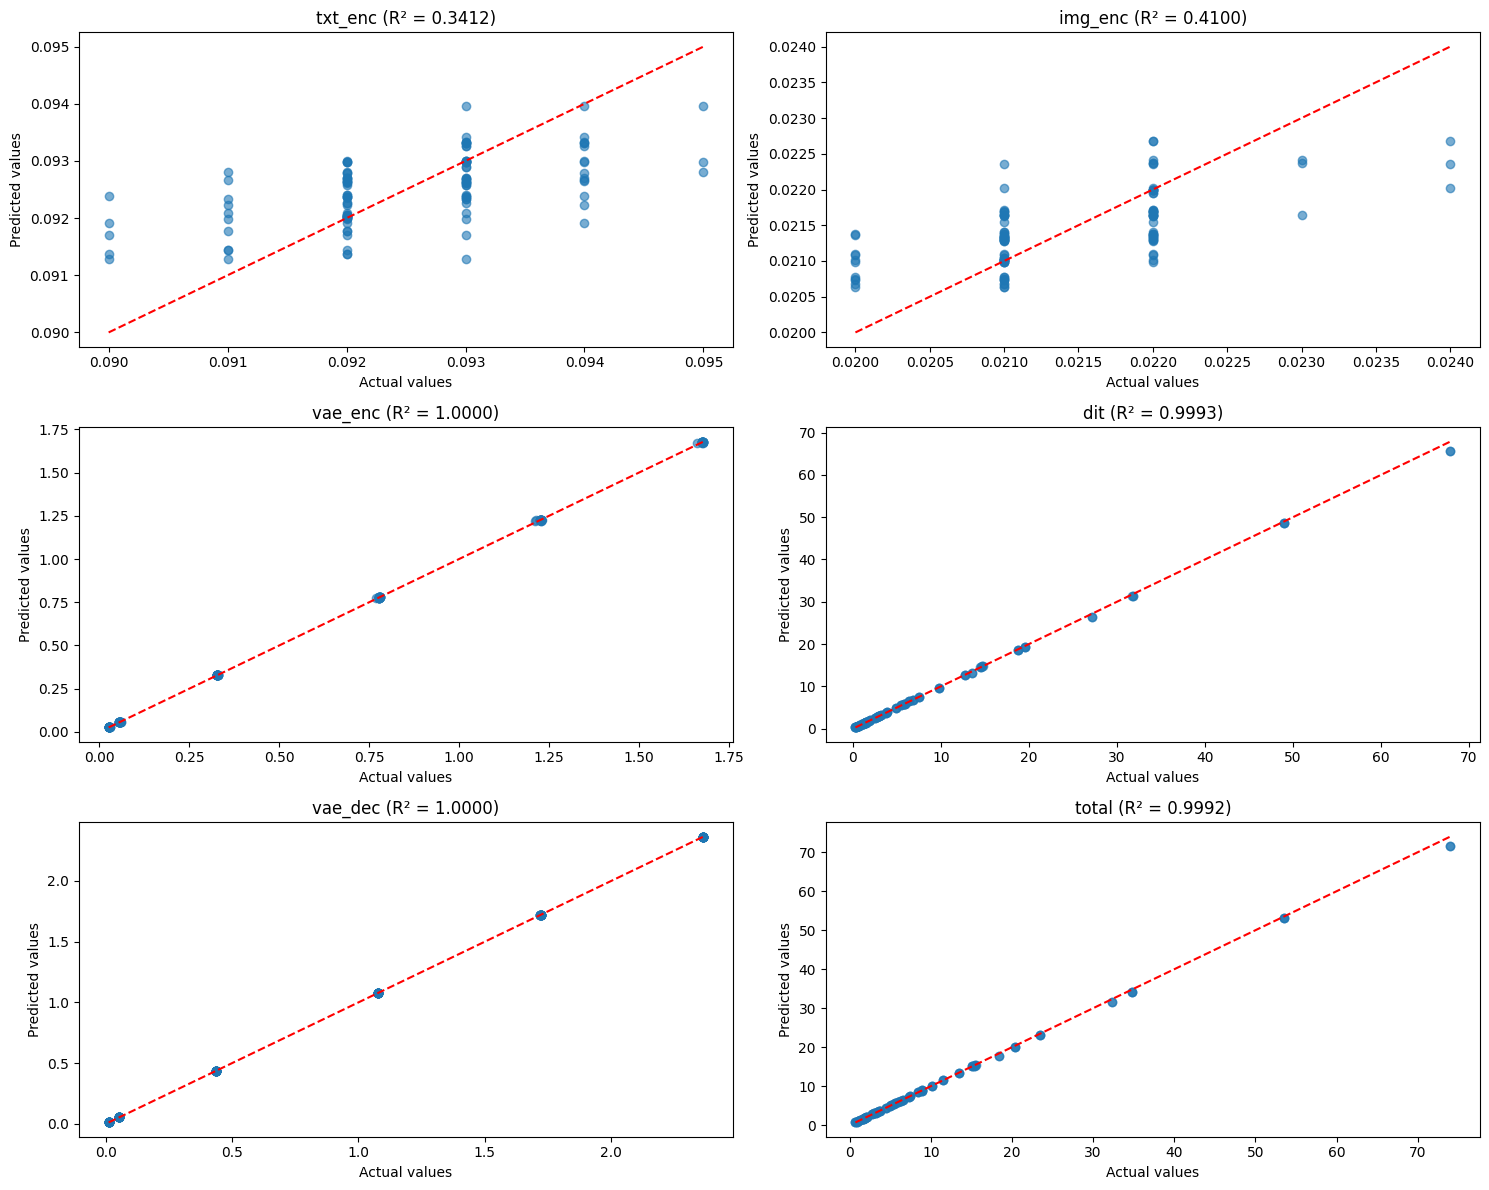

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, target in enumerate(targets):
    # Get the model for this target
    model = models[target]
    
    # Predict values
    y_pred = model.predict(X)
    
    # Plot actual vs predicted
    ax = axes[i]
    ax.scatter(y[target], y_pred, alpha=0.6)
    
    # Add perfect prediction line
    max_val = max(y[target].max(), y_pred.max())
    min_val = min(y[target].min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    # Calculate and display R^2
    r2 = model.score(X, y[target])
    ax.set_title(f'{target} (R² = {r2:.4f})')
    ax.set_xlabel('Actual values')
    ax.set_ylabel('Predicted values')

plt.tight_layout()
plt.show()